##Import librareis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 , os
from google.colab.patches import cv2_imshow
import tensorflow as tf
from tensorflow import keras


## Show Data

In [2]:
imagePath = '/content/drive/MyDrive/Angry'
images = os.listdir(imagePath)
len(images)


250

In [3]:
# read one image
img = cv2.imread(os.path.join(imagePath,images[1]))
img.shape


(224, 224, 3)

In [4]:
img[0][0]

array([48, 48, 48], dtype=uint8)

## prosseccing and cleaning

In [5]:
# transfer color
img= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img.shape

(224, 224)

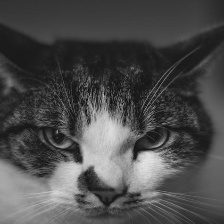

In [6]:

cv2_imshow(img)

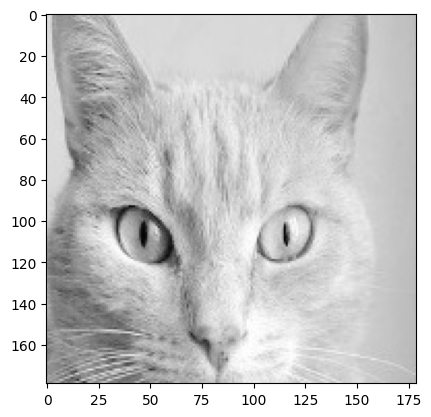

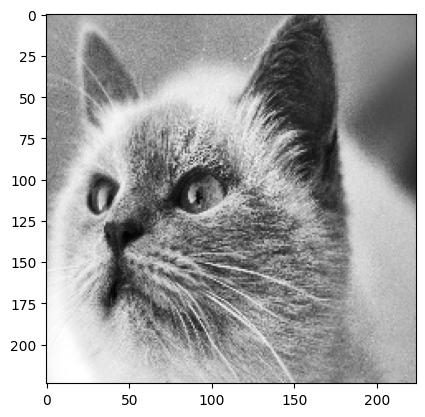

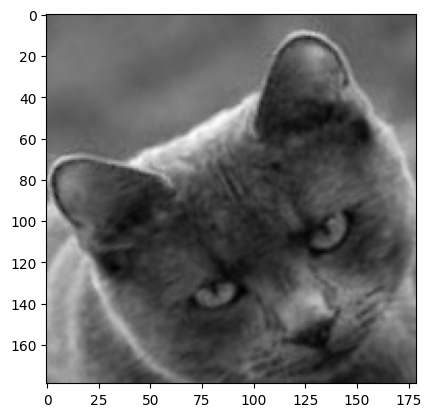

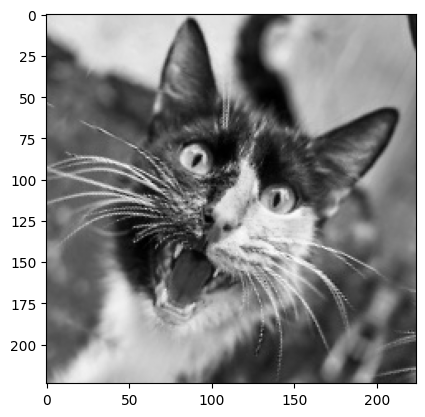

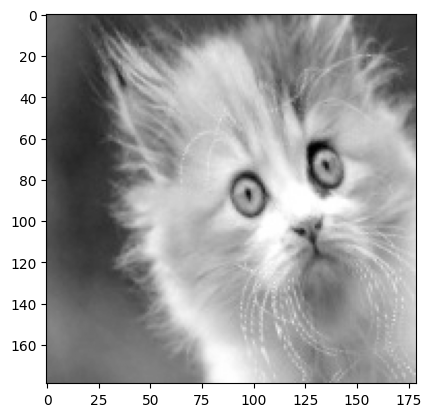

In [7]:
for i in range(5):
  img = cv2.imread(os.path.join(imagePath,np.random.choice(images)))
  img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  plt.imshow(img ,cmap='gray')
  plt.show()

In [8]:
# find the sizes in the folder
allSize = []
for img in images :
  img = cv2.imread(os.path.join(imagePath,img))
  allSize.append(img.shape)

set(allSize)

{(179, 179, 3), (224, 224, 3)}

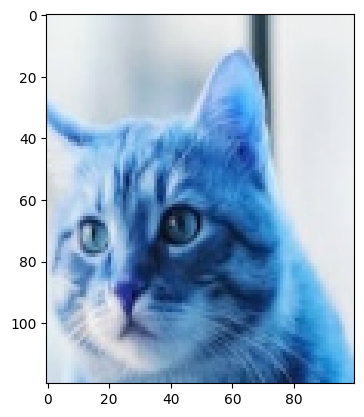

In [9]:
H,W = 100,120
img = cv2.resize(img,(H,W))
plt.imshow(img, cmap='gray')
plt.show()

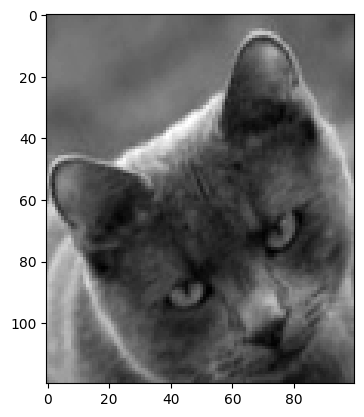

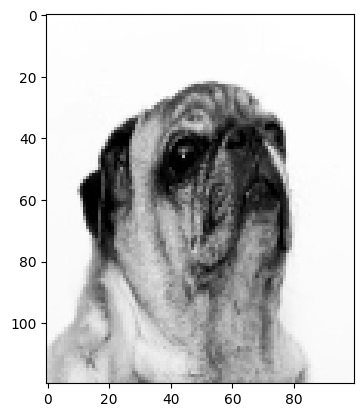

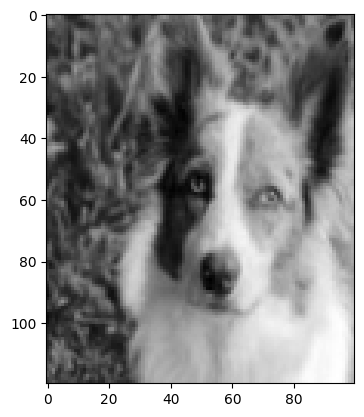

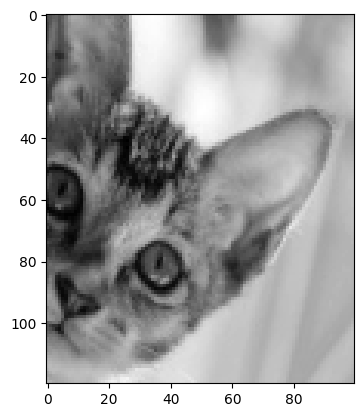

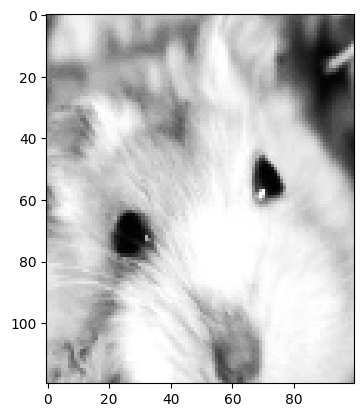

In [10]:
# try the resizs on 5 random images
for i in range(5):
  img = cv2.imread(os.path.join(imagePath,np.random.choice(images)))
  img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  img = cv2.resize(img,(H,W))
  plt.imshow(img, cmap='gray')
  plt.show()

In [11]:
# # Apply resize for all images
# To standardize the input dimensions of the model
ImagesArray = []
for img in images :
  img = cv2.imread(os.path.join(imagePath,img))
  img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  img = cv2.resize(img,(H,W))
  img = img.reshape(H,W,1)
  ImagesArray.append(img)

print(len(ImagesArray))



250


## Splitting the Data

In [13]:
from sklearn.model_selection import train_test_split

# Convert to numpy array
X = np.array(ImagesArray)

# Create dummy labels
y = np.zeros(len(X))

# Normalization
X = X.astype('float32') / 255.0

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')

Shape of X_train: (200, 100, 120, 1)
Shape of X_test: (50, 100, 120, 1)


## Build the neural network

In [14]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3),strides=(1,1),padding='VALID', input_shape=(H, W, 1)),
    keras.layers.MaxPooling2D(pool_size=(2, 2),strides=(2,2)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=32, kernel_size=(4, 4),strides=(1,1),padding='VALID', input_shape=(H, W, 1)),
    keras.layers.MaxPooling2D(pool_size=(2, 2),strides=(2,2)),
    keras.layers.BatchNormalization(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

#compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#fitting
model.fit(X_train, y_train, epochs=10)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 649ms/step - accuracy: 0.6933 - loss: 0.5731
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 1.0000 - loss: 2.2785e-05
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 0.9981 - loss: 0.0407
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 755ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - accuracy: 1.0000 - loss: 2.3207e-06
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 430ms/step - accuracy: 1.0000 - loss: 6.4343e-08
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 721ms/step - accuracy: 1.0000 - loss: 7.5394e-05
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 465ms/step - accuracy: 1.0000 - loss: 3.3309e-08
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 492ms/step - accuracy: 1.0000 - loss: 1.9351e-08
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 1.0000 - loss: 5.1847e-09


### the accuracy is not real , the model just for trial


In [15]:
# summary
print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 118, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 49, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 56, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20608)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,637,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,964,965 (30.38 MB)

 Trainable params: 2,654,945 (10.13 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 5,309,892 (20.26 MB)

None
